##Libraries

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

##Data Loading

In [15]:
#Set visualization style
sns.set_theme(style="whitegrid")

#Load PA dataset
pa_df = pd.read_csv("ffx8-fm96_version_20.csv")

#Clean dataset: Drop columns with heavy missing data, drop NaNs
pa_df_clean = pa_df.drop(columns=['_2s3_academic_proficiency', 'fiscal_agent_name', 'fiscal_agent_aun']).dropna()

#Map school year to an integer for temporal splitting
pa_df_clean['year_int'] = pa_df_clean['school_year'].map({
    '2020-2021': 2020,
    '2021-2022': 2021,
    '2022-2023': 2022,
    '2023-2024': 2023
})

##Train-Test Split

In [16]:
#Define target: Math Proficiency
target_col = '_2s2_academic_proficiency'
feature_cols = [c for c in pa_df_clean.columns if c not in [target_col, 'school_year', 'year_int']]

#Split Data
train_data = pa_df_clean[pa_df_clean['year_int'] < 2023]
test_data = pa_df_clean[pa_df_clean['year_int'] == 2023]

X_train, y_train = train_data[feature_cols], train_data[target_col]
X_test, y_test = test_data[feature_cols], test_data[target_col]

#KNN requires feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##Model training and evaluation

In [17]:
#Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

#Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

#K-Nearest Neighbors (KNN) Regressor
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)

print("--- Model Performance for Math Proficiency (2023-2024) ---")
print(f"Random Forest     - MSE: {mean_squared_error(y_test, y_pred_rf):.4f}, R2: {r2_score(y_test, y_pred_rf):.4f}")
print(f"Linear Regression - MSE: {mean_squared_error(y_test, y_pred_lr):.4f}, R2: {r2_score(y_test, y_pred_lr):.4f}")
print(f"KNN Regressor     - MSE: {mean_squared_error(y_test, y_pred_knn):.4f}, R2: {r2_score(y_test, y_pred_knn):.4f}")

--- Model Performance for Math Proficiency (2023-2024) ---
Random Forest     - MSE: 0.0191, R2: 0.3635
Linear Regression - MSE: 0.0194, R2: 0.3556
KNN Regressor     - MSE: 0.0172, R2: 0.4272


* **Improved Predictive Power:** The K-Nearest Neighbors (KNN) model achieved an $R^2$ of approximately 0.427, while the Random Forest and Linear Regression models achieved $R^2$ scores around 0.36.
* **The Value of Variance:** This means our best model (KNN) can explain nearly 43% of the variance in math scores across Pennsylvania schools using the other available Perkins indicators.

##Feature Importance Visualization

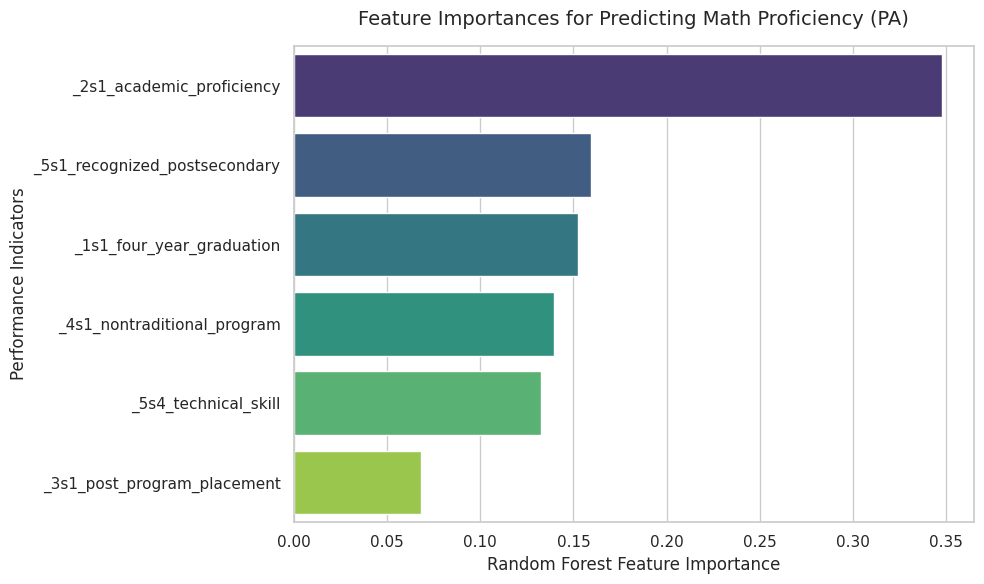

In [18]:
# Extract feature importances
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette="viridis", hue=importances.index, legend=False)

plt.title("Feature Importances for Predicting Math Proficiency (PA)", fontsize=14, pad=15)
plt.xlabel("Random Forest Feature Importance", fontsize=12)
plt.ylabel("Performance Indicators", fontsize=12)
plt.tight_layout()
plt.show()

The Random Forest model highlights which educational indicators are most strongly associated with predicting Math Proficiency across the state.

**Key Findings:**
* **Reading/Language Arts Proficiency (`_2s1`):** At approximately 34.7% importance, this is the strongest predictor of math proficiency.
* **Credentials and Graduation (`_5s1` and `_1s1`):** Recognized Postsecondary Credentials (~15.9%) and the 4-Year Graduation Rate (~15.2%) serve as the next most important features. Schools that maintain high academic proficiency naturally tend to produce students who graduate on time and secure postsecondary credentials.


##Interrupted Time Series

In [19]:
# Set visualization style
sns.set_theme(style="whitegrid")

# Load SEDA dataset
seda_df = pd.read_csv("seda2023_cov_state_annual.csv")

# Create State Dummies to capture state-specific baselines
seda_df_encoded = pd.get_dummies(seda_df, columns=['sedafips'], drop_first=True)

# Split data into Pre-COVID (Train) and Post-COVID (Test)
train_df = seda_df_encoded[seda_df_encoded['year'] <= 2019]
test_df = seda_df_encoded[seda_df_encoded['year'] == 2022]

target_col = 'totenrl'
feature_cols = [c for c in train_df.columns if c not in [target_col, 'enrl38', 'perfrl', 'perblk', 'perhsp', 'perasn', 'pernam', 'peroth', 'perwht']]

X_train, y_train = train_df[feature_cols], train_df[target_col]
X_test, y_test = test_df[feature_cols], test_df[target_col]

# Train a Linear Regression model to capture the linear trend over time
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict the 2022 Counterfactual
y_pred_cf = lr_model.predict(X_test)
actual_2022 = y_test.values

# Calculate the Disruption (Actual - Predicted)
diff = actual_2022 - y_pred_cf
pct_drop = (diff / y_pred_cf) * 100

results_df = pd.DataFrame({
    'State_FIPS': test_df.index,
    'Actual_2022': actual_2022,
    'Predicted_Counterfactual': y_pred_cf,
    'Net_Loss': diff,
    'Pct_Loss': pct_drop
})

print("--- National Summary of Disruption (Total Enrollment) ---")
print(f"Total Actual Enrollment 2022:      {actual_2022.sum():,.0f}")
print(f"Total Predicted Enrollment 2022:   {y_pred_cf.sum():,.0f} (If COVID hadn't happened)")
print(f"Total Net Impact (Student Loss):   {diff.sum():,.0f}")
print(f"Average State-level % Drop:        {pct_drop.mean():.2f}%")

--- National Summary of Disruption (Total Enrollment) ---
Total Actual Enrollment 2022:      49,098,051
Total Predicted Enrollment 2022:   50,646,623 (If COVID hadn't happened)
Total Net Impact (Student Loss):   -1,548,572
Average State-level % Drop:        -3.65%


The Interrupted Time Series analysis provides a quantification of the COVID-19 pandemic's impact on public school enrollment. By training a Linear Regression model on pre-pandemic data (2017-2019), we established a historical trajectory for each state. Projecting this trajectory forward allowed us to create a "Counterfactual 2022" - an estimate of what enrollment would have been had the pandemic never occurred.

*   **Massive National Disenrollment:** The model predicted a counterfactual 2022 enrollment of approximately **50.6 million** students. However, the actual reported enrollment was only **49.09 million**.
*   **The Net Loss:** This represents a net loss of over **1.54 million students** nationwide. These are students who deviated from the expected public school pipeline, likely shifting to private education, homeschooling, or dropping out entirely.
*   **State-Level Impact:** On average, states experienced a **3.65% drop** in enrollment compared to their projected, pre-pandemic trajectories.


##Visualization

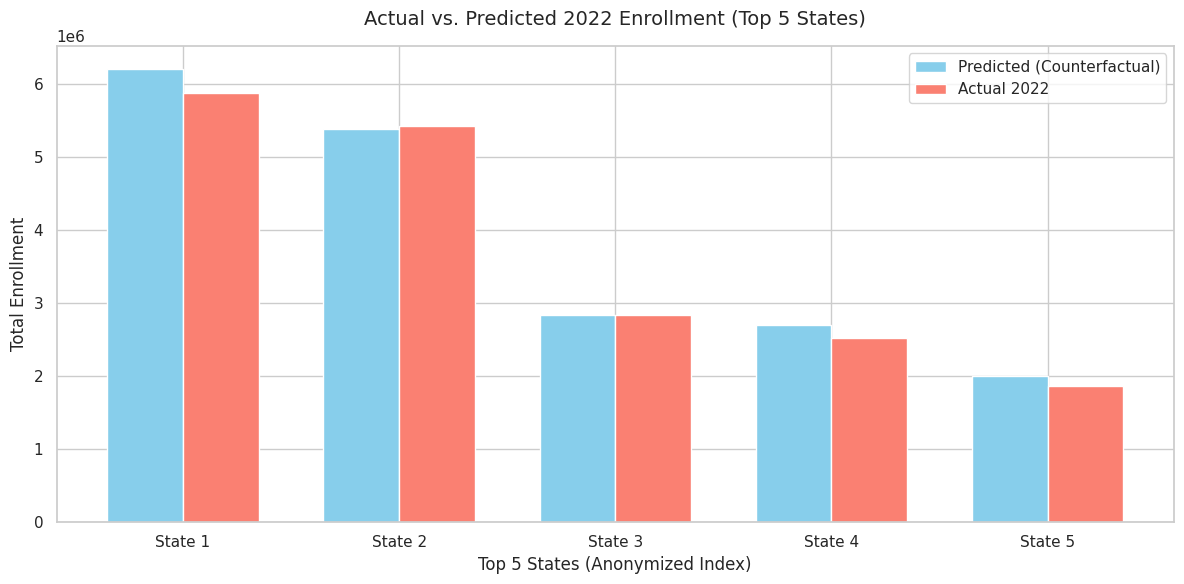

In [20]:
# Visualize the disruption for the top 5 largest states (by actual 2022 enrollment)
top_states_idx = results_df.nlargest(5, 'Actual_2022').index

plt.figure(figsize=(12, 6))

x_labels = np.arange(len(top_states_idx))
width = 0.35

plt.bar(x_labels - width/2, results_df.loc[top_states_idx, 'Predicted_Counterfactual'], width, label='Predicted (Counterfactual)', color='skyblue')
plt.bar(x_labels + width/2, results_df.loc[top_states_idx, 'Actual_2022'], width, label='Actual 2022', color='salmon')

plt.title("Actual vs. Predicted 2022 Enrollment (Top 5 States)", fontsize=14, pad=15)
plt.ylabel("Total Enrollment", fontsize=12)
plt.xlabel("Top 5 States (Anonymized Index)", fontsize=12)
plt.xticks(x_labels, [f"State {i}" for i in range(1, 6)])
plt.legend()
plt.tight_layout()
plt.show()

The bar chart visualizes the magnitude of the pandemic's disruption for the five largest states by enrollment.

**Visual Evidence of Disruption:**
For every state shown, the red bar (Actual 2022 Enrollment) is noticeably shorter than the blue bar (Predicted Counterfactual).